## STEP 1 : Check GPU & Install Libraries
 Select T4 GPU before running this.

In [1]:
# Check GPU availability
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'  PyTorch version : {torch.__version__}')
print(f'  Device selected : {device}')
if torch.cuda.is_available():
    print(f'  GPU name        : {torch.cuda.get_device_name(0)}')
    print(f'  GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU found. Go to Runtime -> Change runtime type -> GPU')


  PyTorch version : 2.10.0+cu128
  Device selected : cuda
  GPU name        : Tesla T4
  GPU memory      : 15.6 GB


In [2]:
# Install any missing libraries (most are pre-installed in Colab)
!pip install -q torch torchvision matplotlib seaborn scikit-learn pillow

print('All libraries ready!')

All libraries ready!


## STEP 2 : Mount Google Drive & Verify Dataset
 Connect to your Google Drive and confirm the dataset folder `ANGKA ARAB` has sub-folders named `0` to `9`.


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print('Google Drive mounted at /content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive


In [4]:
import shutil, time
import os

DRIVE_DIR = '/content/drive/MyDrive/ANGKA ARAB'
LOCAL_DIR = '/content/data'   #  fast local SSD

print('Copying dataset from Drive to local disk...')
t0 = time.time()

if os.path.exists(LOCAL_DIR):
    shutil.rmtree(LOCAL_DIR)

shutil.copytree(DRIVE_DIR, LOCAL_DIR)

print(f'Done in {time.time()-t0:.1f} seconds!')

DATA_DIR = LOCAL_DIR  # use this from now on
print(f'DATA_DIR is now: {DATA_DIR}')

Copying dataset from Drive to local disk...
Done in 94.1 seconds!
DATA_DIR is now: /content/data


In [5]:
import os

# Dataset path
DATA_DIR = '/content/drive/MyDrive/ANGKA ARAB'

# Verify the folder exists
if not os.path.isdir(DATA_DIR):
    print(f'Folder not found: {DATA_DIR}')
    print('   Check the folder name in your Google Drive (case-sensitive).')
else:
    print(f'Dataset folder found: {DATA_DIR}')
    print()

    # List class sub-folders and count images
    print('Class folders and image counts:')
    print('-' * 38)
    total = 0
    found_classes = []

    for cls in sorted(os.listdir(DATA_DIR)):
        cls_path = os.path.join(DATA_DIR, cls)
        if os.path.isdir(cls_path):
            imgs = [f for f in os.listdir(cls_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
            count = len(imgs)
            print(f'  Digit  {cls:>2}  ->>  {count:>5} images')
            total += count
            found_classes.append(cls)

    print('-' * 30)
    print(f'  TOTAL      ->  {total:>5} images')
    print(f'  Classes found: {found_classes}')

    if len(found_classes) == 10:
        print('\n All 10 digit classes confirmed!')
    else:
        print(f'\n Expected 10 classes but found {len(found_classes)}. Check your folder.')

Dataset folder found: /content/drive/MyDrive/ANGKA ARAB

Class folders and image counts:
--------------------------------------
  Digit   0  ->>    935 images
  Digit   1  ->>    935 images
  Digit   2  ->>    935 images
  Digit   3  ->>    935 images
  Digit   4  ->>    935 images
  Digit   5  ->>    935 images
  Digit   6  ->>    935 images
  Digit   7  ->>    935 images
  Digit   8  ->>    935 images
  Digit   9  ->>    935 images
------------------------------
  TOTAL      ->   9350 images
  Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

 All 10 digit classes confirmed!


## STEP 3 : Explore & Visualize the Dataset
 Display sample images from each class and check the class balance.

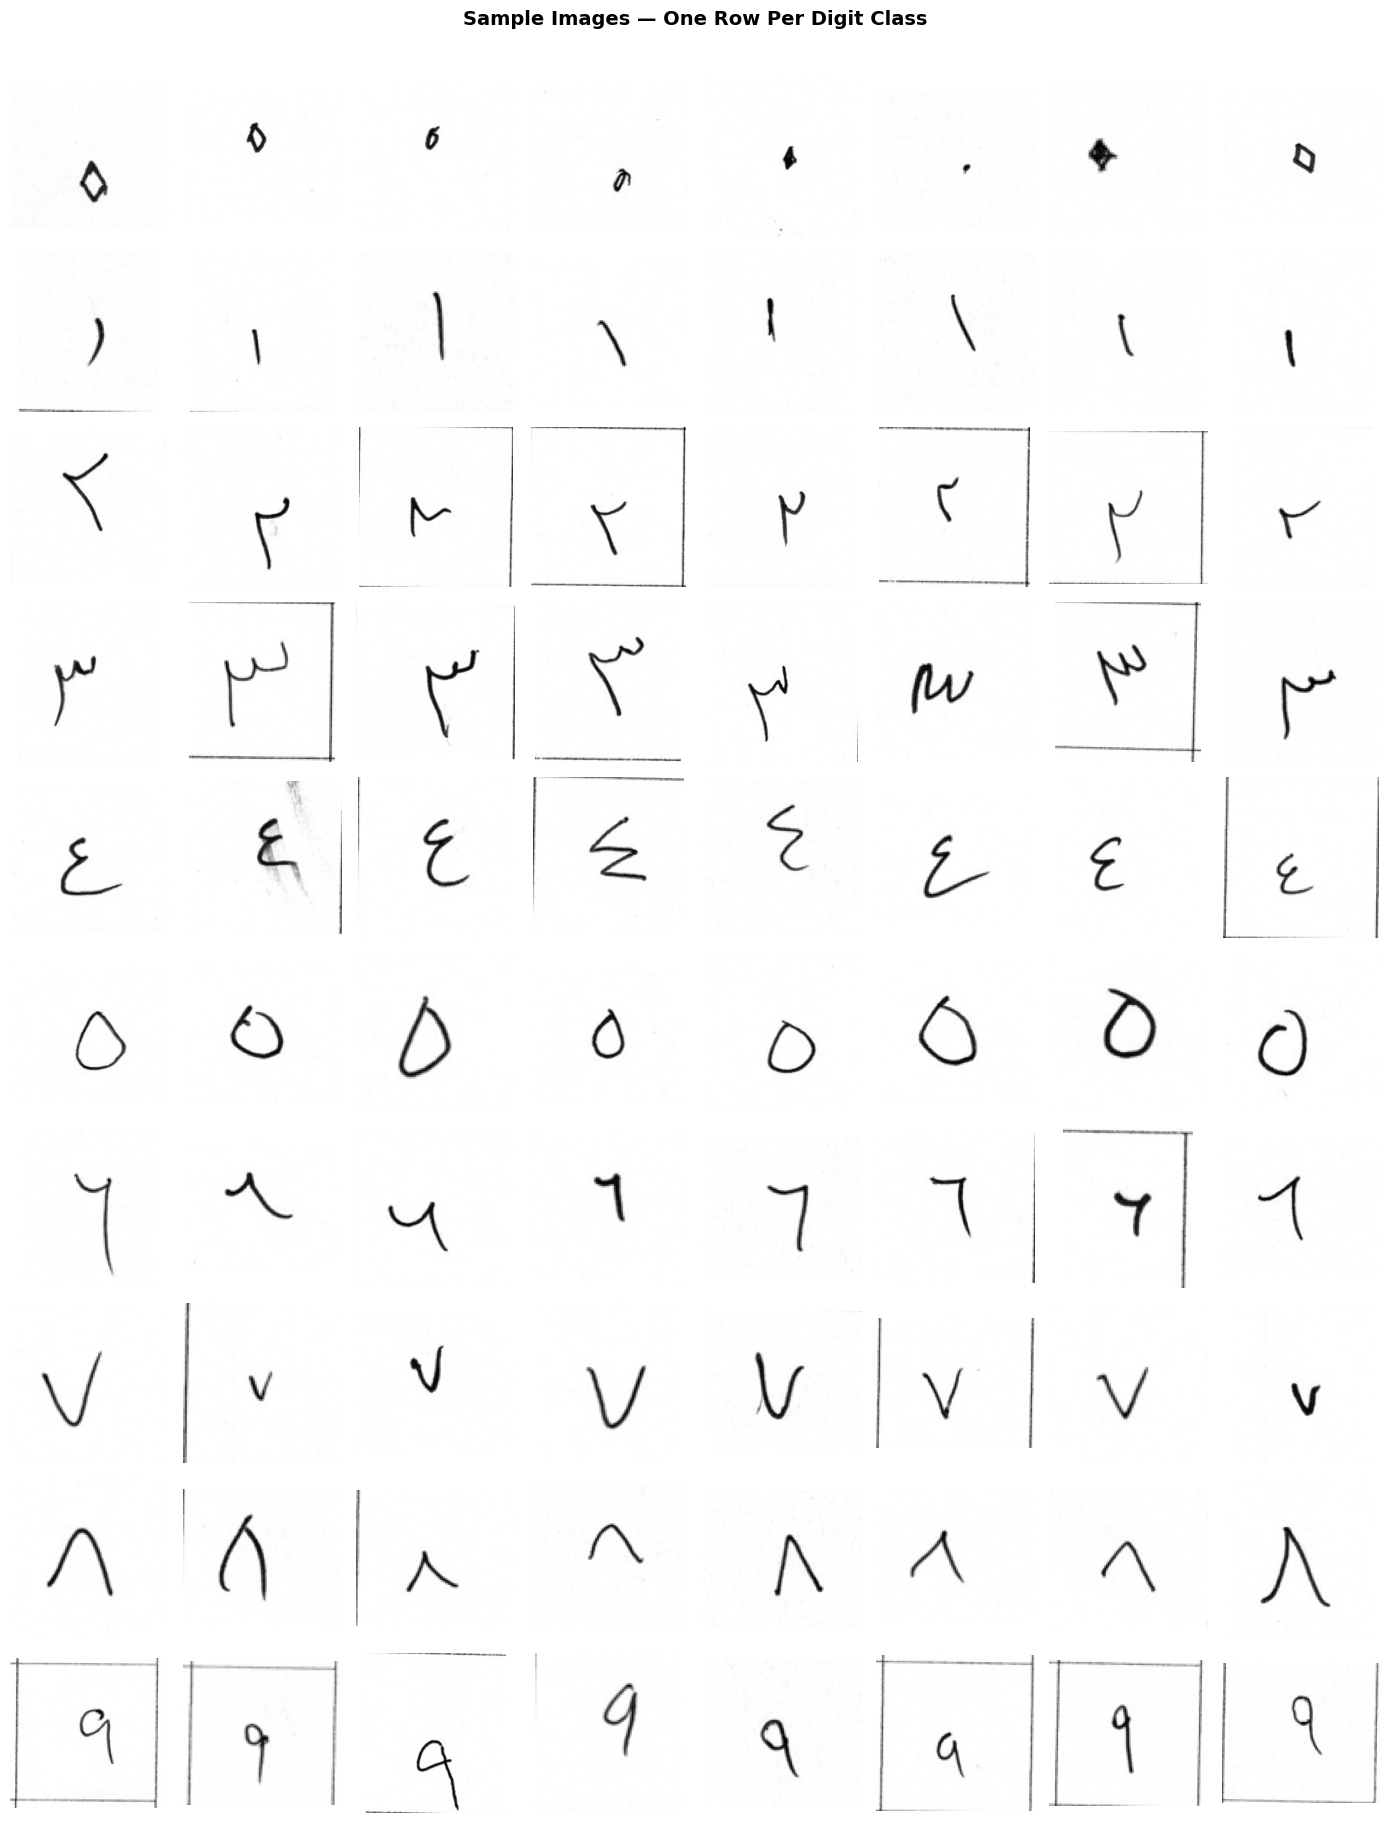

Sample grid displayed  (8 samples per class)


In [6]:
# Show 8 sample images per digit class
import matplotlib.pyplot as plt
from PIL import Image
import random, os

fig, axes = plt.subplots(10, 8, figsize=(14, 18))
fig.suptitle('Sample Images - One Row Per Digit Class', fontsize=14,
             fontweight='bold', y=1.01)

for digit in range(10):
    cls_dir = os.path.join(DATA_DIR, str(digit))
    files   = [f for f in os.listdir(cls_dir)
               if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    samples = random.sample(files, min(8, len(files)))

    for col, fname in enumerate(samples):
        ax  = axes[digit][col]
        img = Image.open(os.path.join(cls_dir, fname)).convert('L')
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'Digit {digit}', fontsize=10, fontweight='bold',
                          rotation=0, labelpad=38, va='center')

plt.tight_layout()
plt.savefig('/content/dataset_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Sample grid displayed  (8 samples per class)')

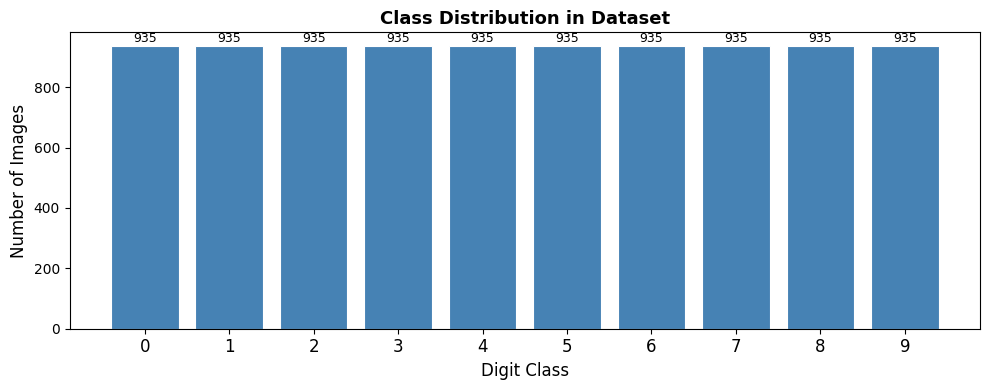

Class distribution chart saved
Dataset is well-balanced


In [7]:
# Class distribution bar chart
import matplotlib.pyplot as plt

counts = []
for d in range(10):
    cls_dir = os.path.join(DATA_DIR, str(d))
    n = len([f for f in os.listdir(cls_dir)
             if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])
    counts.append(n)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(10), counts, color='steelblue', edgecolor='white', linewidth=0.8)
ax.set_xticks(range(10))
ax.set_xticklabels([str(d) for d in range(10)], fontsize=12)
ax.set_xlabel('Digit Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Class Distribution in Dataset', fontsize=13, fontweight='bold')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=120)
plt.show()
print('Class distribution chart saved')

# Balance check
min_c, max_c = min(counts), max(counts)
if max_c - min_c < 0.2 * max_c:
    print('Dataset is well-balanced')
else:
    print(f'Imbalance detected: min={min_c}, max={max_c} - consider weighted sampling')

## STEP 4 : Preprocessing & Data Loaders
 Apply transforms (resize, normalize, augmentation) and split data into Train / Val / Test loaders.

In [8]:
from torchvision import transforms

#  Config
IMG_SIZE   = 32
BATCH_SIZE = 64
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15
SEED       = 42

# Train transform (with augmentation)
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),   # convert to single channel
    transforms.Resize((IMG_SIZE, IMG_SIZE)),        # resize to 32×32
    transforms.RandomRotation(10),                  # rotate ±10°
    transforms.RandomAffine(degrees=0,
                            translate=(0.05, 0.05)), # shift ±5%
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),    # scale to [-1, 1]
])

#  Val / Test transform (no augmentation)
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

print('Transforms defined:')
print('  Train  : Grayscale -> Resize(32×32) -> Rotation -> Affine -> Normalize')
print('  Val/Test: Grayscale -> Resize(32×32) -> Normalize')

Transforms defined:
  Train  : Grayscale -> Resize(32×32) -> Rotation -> Affine -> Normalize
  Val/Test: Grayscale -> Resize(32×32) -> Normalize


In [9]:
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import ImageFolder

# Helper: apply different transforms per split
class TransformedSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


# Load full dataset (raw PIL images, no transform yet)
full_dataset = ImageFolder(root=DATA_DIR)
CLASSES      = full_dataset.classes
N            = len(full_dataset)

# Compute split sizes
n_test  = int(N * TEST_SPLIT)
n_val   = int(N * VAL_SPLIT)
n_train = N - n_test - n_val

# Split
train_sub, val_sub, test_sub = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# DataLoaders
train_loader = DataLoader(TransformedSubset(train_sub, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(TransformedSubset(val_sub,   eval_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(TransformedSubset(test_sub,  eval_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print('Data loaders ready!')
print(f'   Total   : {N:,} images')
print(f'   Train   : {n_train:,}  ({n_train/N*100:.0f}%)')
print(f'   Val     : {n_val:,}  ({n_val/N*100:.0f}%)')
print(f'   Test    : {n_test:,}  ({n_test/N*100:.0f}%)')
print(f'   Classes : {CLASSES}')

Data loaders ready!
   Total   : 9,350 images
   Train   : 6,546  (70%)
   Val     : 1,402  (15%)
   Test    : 1,402  (15%)
   Classes : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


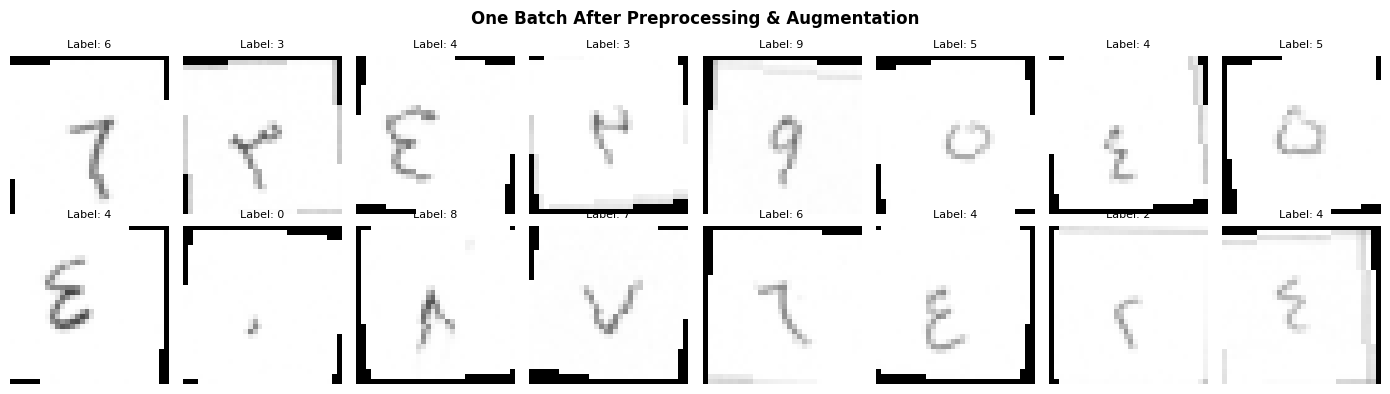

Batch shape: torch.Size([64, 1, 32, 32])  ->  (batch_size × channels × H × W)


In [10]:
# Visually verify one batch after preprocessing
import matplotlib.pyplot as plt

imgs, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('One Batch After Preprocessing & Augmentation', fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    img = imgs[i].squeeze().numpy()
    img = (img * 0.5) + 0.5        # un-normalize for display
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {CLASSES[labels[i]]}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Batch shape: {imgs.shape}  ->  (batch_size × channels × H × W)')

## STEP 5 : Build the CNN Model
 Define the `ArabicNumeralCNN` and confirm it works with a dummy input.

In [11]:
import torch.nn as nn

class ArabicNumeralCNN(nn.Module):
    """
    Lightweight 3-Block CNN for 10-class digit recognition.

    Block 1 : Conv(1->32,  3×3) + BatchNorm + ReLU + MaxPool  ->  16×16
    Block 2 : Conv(32->64, 3×3) + BatchNorm + ReLU + MaxPool  ->   8×8
    Block 3 : Conv(64->128,3×3) + BatchNorm + ReLU + MaxPool  ->   4×4
    Head    : Flatten -> FC(2048->512) -> Dropout(0.5) -> FC(512->10)
    """
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # --- Block 1 ------------------------------------
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),            # 32×32 -> 16×16

            # --- Block 2 ------------------------------------
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),            # 16×16 -> 8×8

            # ---- Block 3 ------------------------------------
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),            # 8×8 -> 4×4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ------ Build & verify ---------------------------------------------------------------
model = ArabicNumeralCNN(num_classes=10).to(device)

dummy  = torch.zeros(1, 1, 32, 32).to(device)   # fake single image
output = model(dummy)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Model built successfully!')
print(f'   Input  shape : {dummy.shape}')
print(f'   Output shape : {output.shape}  (10 class logits)')
print(f'   Total params : {params:,}')
print()
print(model)

Model built successfully!
   Input  shape : torch.Size([1, 1, 32, 32])
   Output shape : torch.Size([1, 10])  (10 class logits)
   Total params : 1,147,338

ArabicNumeralCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=

## STEP 6 : Train the Model
 Train for 25 epochs. The best checkpoint (by val accuracy) is auto-saved as `best_model.pth`.

*Expected time on T4 GPU: ~3–6 minutes total.*

In [12]:
import torch.optim as optim

EPOCHS = 25
LR     = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

print('Training configuration set:')
print(f'   Loss function : CrossEntropyLoss')
print(f'   Optimizer     : Adam  (lr={LR})')
print(f'   LR Scheduler  : StepLR - halved every 8 epochs')
print(f'   Epochs        : {EPOCHS}')
print(f'   Batch size    : {BATCH_SIZE}')

Training configuration set:
   Loss function : CrossEntropyLoss
   Optimizer     : Adam  (lr=0.001)
   LR Scheduler  : StepLR — halved every 8 epochs
   Epochs        : 25
   Batch size    : 64


In [13]:
# ------ Training loop ------------------------------------------------------------
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):

    # ------ Train phase ------------------------------------------------------------
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        t_loss    += loss.item() * imgs.size(0)
        t_correct += (outputs.argmax(1) == labels).sum().item()
        t_total   += imgs.size(0)

    # ------ Validation phase ---------------------------------------------------------
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)

            v_loss    += loss.item() * imgs.size(0)
            v_correct += (outputs.argmax(1) == labels).sum().item()
            v_total   += imgs.size(0)

    scheduler.step()

    t_l = t_loss / t_total;  t_a = t_correct / t_total
    v_l = v_loss / v_total;  v_a = v_correct / v_total

    history['train_loss'].append(t_l);  history['val_loss'].append(v_l)
    history['train_acc'].append(t_a);   history['val_acc'].append(v_a)

    # Save best checkpoint
    if v_a > best_val_acc:
        best_val_acc = v_a
        torch.save(model.state_dict(), '/content/best_model.pth')
        tag = '   best saved'
    else:
        tag = ''

    print(f'Epoch [{epoch:2d}/{EPOCHS}]  '
          f'Train Loss: {t_l:.4f}  Acc: {t_a*100:5.2f}%  |  '
          f'Val Loss: {v_l:.4f}  Acc: {v_a*100:5.2f}%{tag}')

print()
print(f'Training complete!  Best Val Accuracy: {best_val_acc*100:.2f}%')

Epoch [ 1/25]  Train Loss: 1.6847  Acc: 42.00%  |  Val Loss: 0.7171  Acc: 74.68%   best saved
Epoch [ 2/25]  Train Loss: 0.5298  Acc: 82.66%  |  Val Loss: 0.2273  Acc: 92.80%   best saved
Epoch [ 3/25]  Train Loss: 0.3373  Acc: 89.41%  |  Val Loss: 0.2317  Acc: 91.01%
Epoch [ 4/25]  Train Loss: 0.2533  Acc: 92.12%  |  Val Loss: 0.1941  Acc: 92.80%
Epoch [ 5/25]  Train Loss: 0.2086  Acc: 93.22%  |  Val Loss: 0.1397  Acc: 95.79%   best saved
Epoch [ 6/25]  Train Loss: 0.1864  Acc: 93.90%  |  Val Loss: 0.1577  Acc: 94.65%
Epoch [ 7/25]  Train Loss: 0.1723  Acc: 94.73%  |  Val Loss: 0.1342  Acc: 95.44%
Epoch [ 8/25]  Train Loss: 0.1463  Acc: 95.26%  |  Val Loss: 0.1296  Acc: 96.36%   best saved
Epoch [ 9/25]  Train Loss: 0.1133  Acc: 96.61%  |  Val Loss: 0.0671  Acc: 97.93%   best saved
Epoch [10/25]  Train Loss: 0.1075  Acc: 96.61%  |  Val Loss: 0.0844  Acc: 97.57%
Epoch [11/25]  Train Loss: 0.0966  Acc: 96.68%  |  Val Loss: 0.1127  Acc: 96.08%
Epoch [12/25]  Train Loss: 0.1043  Acc: 96.6

## STEP 7 : Plot Training Curves
 Check for convergence and overfitting by plotting loss and accuracy over all epochs.

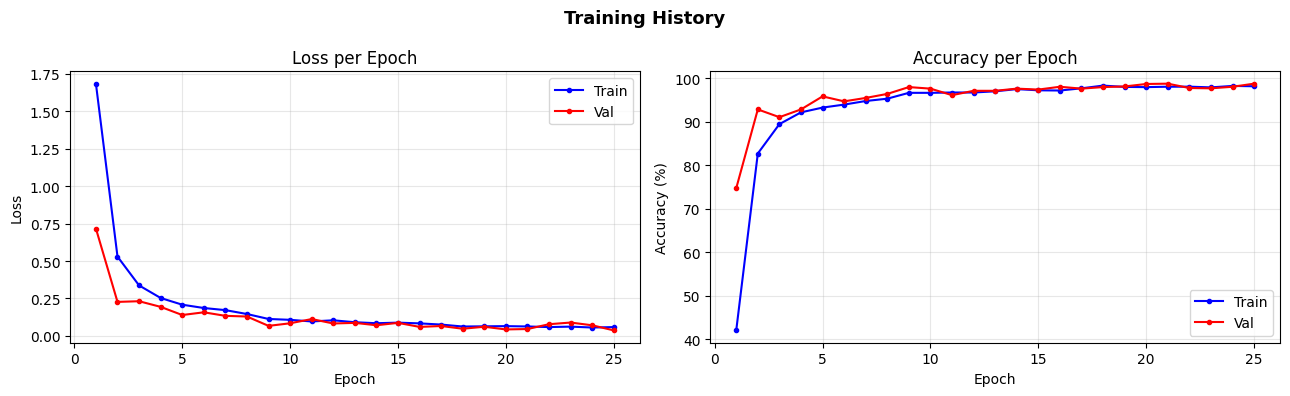

Training curves saved -> /content/training_curves.png
   Final Train Acc : 98.12%
   Final Val Acc   : 98.72%
   Best Val Acc    : 98.72%  (epoch 21)


In [14]:
import matplotlib.pyplot as plt

ep = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training History', fontsize=13, fontweight='bold')

# ------ Loss ------
axes[0].plot(ep, history['train_loss'], 'b-o', markersize=3, label='Train')
axes[0].plot(ep, history['val_loss'],   'r-o', markersize=3, label='Val')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ------ Accuracy ------
axes[1].plot(ep, [a * 100 for a in history['train_acc']], 'b-o', markersize=3, label='Train')
axes[1].plot(ep, [a * 100 for a in history['val_acc']],   'r-o', markersize=3, label='Val')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print('Training curves saved -> /content/training_curves.png')

# Quick summary
print(f'   Final Train Acc : {history["train_acc"][-1]*100:.2f}%')
print(f'   Final Val Acc   : {history["val_acc"][-1]*100:.2f}%')
print(f'   Best Val Acc    : {max(history["val_acc"])*100:.2f}%  (epoch {history["val_acc"].index(max(history["val_acc"]))+1})')

## STEP 8 : Evaluate on the Test Set
 Load the best saved checkpoint and measure final accuracy + full per-class report.

In [15]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Load best checkpoint
model.load_state_dict(torch.load('/content/best_model.pth', map_location=device))
model.eval()
print('Best model checkpoint loaded.')

# Run inference on test set
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs.to(device))
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

test_acc = accuracy_score(y_true, y_pred)

print()
print('=' * 55)
print(f'Test Accuracy : {test_acc * 100:.2f}%')
print('=' * 55)
print()
print('Per-class Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASSES))

Best model checkpoint loaded.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Test Accuracy : 98.07%

Per-class Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       152
           1       0.98      1.00      0.99       130
           2       0.92      0.97      0.94       145
           3       0.98      0.92      0.95       158
           4       1.00      0.99      1.00       127
           5       0.98      0.98      0.98       133
           6       0.99      0.99      0.99       129
           7       0.99      0.99      0.99       145
           8       0.99      1.00      1.00       141
           9       0.99      1.00      0.99       142

    accuracy                           0.98      1402
   macro avg       0.98      0.98      0.98      1402
weighted avg       0.98      0.98      0.98      1402



## STEP 9 : Confusion Matrix
 Visualize exactly which digit pairs the model confuses most.

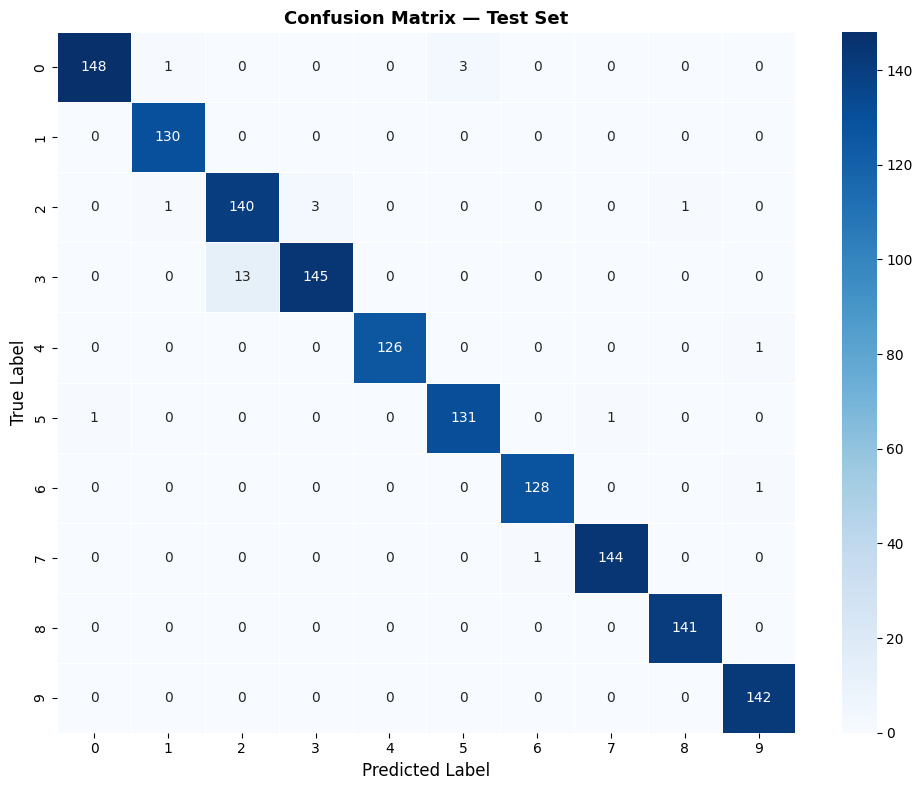

Confusion matrix saved -> /content/confusion_matrix.png

Top misclassified pairs (true -> predicted):
  Digit 3  ->  predicted as  2  :  13 times
  Digit 0  ->  predicted as  5  :  3 times
  Digit 2  ->  predicted as  3  :  3 times
  Digit 0  ->  predicted as  1  :  1 times
  Digit 2  ->  predicted as  1  :  1 times


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved -> /content/confusion_matrix.png')

# Show top confused pairs
import numpy as np
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
print('\nTop misclassified pairs (true -> predicted):')
for _ in range(5):
    idx = np.unravel_index(cm_off.argmax(), cm_off.shape)
    if cm_off[idx] == 0:
        break
    print(f'  Digit {CLASSES[idx[0]]}  ->  predicted as  {CLASSES[idx[1]]}  :  {cm_off[idx]} times')
    cm_off[idx] = 0

## STEP 10 : Sample Predictions
 See actual test images with their true and predicted labels.
- **Green** = correct prediction
- **Red** = wrong prediction

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


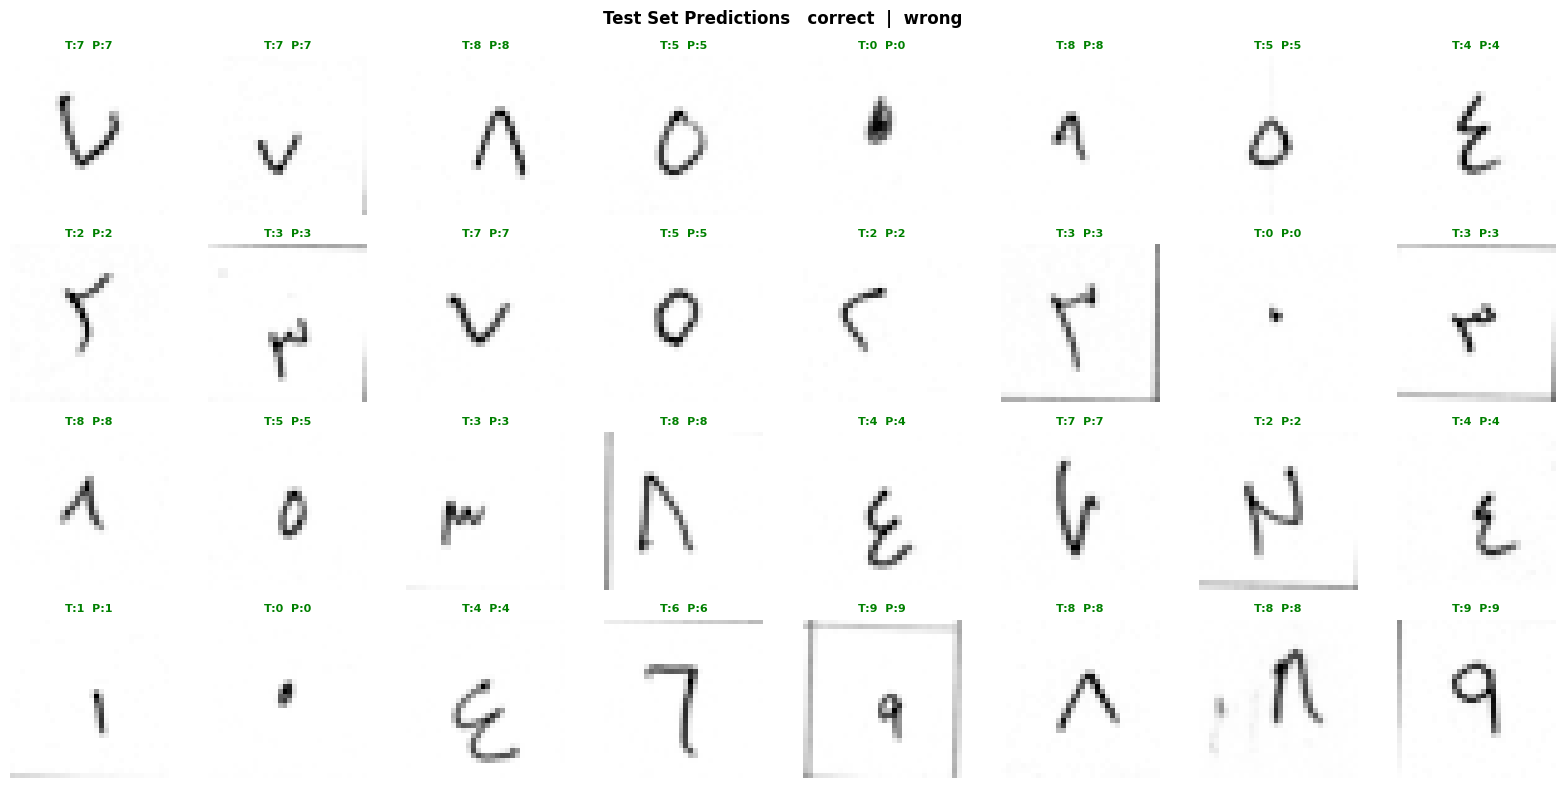

Sample predictions saved -> /content/sample_predictions.png


In [17]:
import matplotlib.pyplot as plt

model.eval()
imgs_buf, preds_buf, labels_buf = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs.to(device))
        preds   = outputs.argmax(dim=1).cpu()
        imgs_buf.extend(imgs)
        preds_buf.extend(preds)
        labels_buf.extend(labels)
        if len(imgs_buf) >= 32:
            break

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Test Set Predictions   correct  |  wrong',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    img      = imgs_buf[i].squeeze().numpy()
    img      = (img * 0.5) + 0.5         # un-normalize
    true_cls = CLASSES[labels_buf[i]]
    pred_cls = CLASSES[preds_buf[i]]
    color    = 'green' if true_cls == pred_cls else 'red'
    ax.imshow(img, cmap='gray')
    ax.set_title(f'T:{true_cls}  P:{pred_cls}', color=color,
                 fontsize=8, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/sample_predictions.png', dpi=150)
plt.show()
print('Sample predictions saved -> /content/sample_predictions.png')

## STEP 11 : Save Model & Download Files
 Save the trained model and download all output files to your computer.

In [20]:
import os

# Save model weights
torch.save(model.state_dict(), '/content/arabic_numerals_weights.pth')
torch.save(model,              '/content/arabic_numerals_full_model.pth')

# List all saved files
output_files = [
    '/content/best_model.pth',
    '/content/arabic_numerals_weights.pth',
    '/content/arabic_numerals_full_model.pth',
    '/content/training_curves.png',
    '/content/confusion_matrix.png',
    '/content/sample_predictions.png',
    '/content/dataset_samples.png',
    '/content/class_distribution.png',
]

print(' Saved output files:')
print('-' * 55)
for f in output_files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f' {os.path.basename(f):<40} {size:>7.1f} KB')
    else:
        print(f' {os.path.basename(f):<40} not found')
print('-' * 55)

 Saved output files:
-------------------------------------------------------
 best_model.pth                            4492.2 KB
 arabic_numerals_weights.pth               4492.8 KB
 arabic_numerals_full_model.pth            4497.7 KB
 training_curves.png                         74.1 KB
 confusion_matrix.png                        62.2 KB
 sample_predictions.png                      75.7 KB
 dataset_samples.png                        846.8 KB
 class_distribution.png                      25.7 KB
-------------------------------------------------------


In [21]:
# Download files to your compute
from google.colab import files

to_download = [
    '/content/arabic_numerals_weights.pth',
    '/content/training_curves.png',
    '/content/confusion_matrix.png',
    '/content/sample_predictions.png',
]

for f in to_download:
    if os.path.exists(f):
        files.download(f)
        print(f'Downloading: {os.path.basename(f)}')
    else:
        print(f'Not found: {f}')

print('\n Done!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: arabic_numerals_weights.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: sample_predictions.png

 Done!


## Project Summary!

| Item | Detail |
|------|--------|
| **Dataset path** | `/content/drive/MyDrive/ANGKA ARAB` |
| **Model** | ArabicNumeralCNN - 3 Conv Blocks + FC head |
| **Input** | Grayscale 32×32 images |
| **Split** | 70% Train / 15% Val / 15% Test |
| **Optimizer** | Adam + StepLR |
| **Epochs** | 25 |
| **Output files** | weights, training curves, confusion matrix, sample predictions |

## Note
A fixed random seed (seed=42) is used for the train/val/test
split. Small differences in accuracy (±0.5%) between runs
are normal due to dropout and data augmentation randomness.
Results in the report are from one run.